In [19]:
from pathlib import Path
import re
import numpy as np
import pandas as pd

pd.set_option("display.max_colwidth", 120)
SEED = 42
rng = np.random.default_rng(SEED)

REPO_RAW = Path("../data/raw/bank_transactions.csv")
file_path = REPO_RAW if REPO_RAW.exists() else Path(r"C:\Users\This pc\bank_transactions.csv")
OUT_DIR = Path("../data/processed") if REPO_RAW.exists() else file_path.parent / "finsight_processed"

print("File found:", file_path.exists())

File found: True


In [2]:
raw = pd.read_csv(file_path)
print(raw.shape)
display(raw.dtypes)
raw.head()

(258779, 8)


client_id        int64
bank_id          int64
account_id       int64
txn_id           int64
txn_date        object
description     object
amount         float64
category        object
dtype: object

,client_id,bank_id,account_id,txn_id,txn_date,description,amount,category
0,1,1,1,4,2023-09-29 00:00:00,Earnin PAYMENT Donatas Danyal,20.0,Loans
1,1,1,1,3,2023-08-14 00:00:00,ONLINE TRANSFER FROM NDonatas DanyalDA O CARSON BUSINESS CHECKING 1216 1216,25.0,Transfer Credit
2,1,1,1,5,2023-09-25 00:00:00,MONEY TRANSFER AUTHORIZED ON 09/25 FROM Earnin CDAEJ_B CA S583269001...,20.0,Loans
3,1,1,2,1,2023-06-02 00:00:00,ONLINE TRANSFER FROM CARSON N EVERYDAY CHECKING 1216 1216,16.0,Transfer Credit
4,1,1,2,2,2023-06-01 00:00:00,ONLINE TRANSFER FROM CARSON N EVERYDAY CHECKING 1216 1216,4.0,Transfer Credit


In [3]:
audit = {
    "rows": len(raw),
    "missing_per_column": raw.isna().sum().to_dict(),
    "full_row_duplicates": int(raw.duplicated().sum()),
    "same_desc_amount_date": int(raw.duplicated(subset=["description", "amount", "txn_date"]).sum()),
    "unique_descriptions": raw["description"].nunique(),
    "raw_categories": raw["category"].nunique(),
    "date_range": (raw["txn_date"].min(), raw["txn_date"].max()),
}
for k, v in audit.items():
    print(f"{k}: {v}")

raw["category"].value_counts(dropna=False)

rows: 258779
missing_per_column: {'client_id': 0, 'bank_id': 0, 'account_id': 0, 'txn_id': 0, 'txn_date': 0, 'description': 0, 'amount': 0, 'category': 257}
full_row_duplicates: 0
same_desc_amount_date: 22990
unique_descriptions: 102108
raw_categories: 33
date_range: ('2023-06-01 00:00:00', '2023-09-30 00:00:00')


category
Uncategorized                 29392
Third Party                   28714
Restaurants                   26367
Transfer Credit               21561
Loans                         19605
Convenience Stores            18630
Supermarkets and Groceries    16750
Transfer Debit                15114
Gas Stations                  12919
Internal Account Transfer     11983
Payroll                        8100
Shops                          7418
Bank Fees                      6432
Transfer                       6275
ATM                            5672
Transfer Deposit               4976
Digital Entertainment          4525
Utilities                      4118
Clothing and Accessories       3190
Department Stores              2002
Insurance                      1754
Service                         910
Arts and Entertainment          397
Travel                          367
Food and Beverage Services      343
Interest                        280
NaN                             257
Check Deposit      

In [4]:
# IDs carry no predictive value for what a transaction IS 
df = raw.drop(columns=["client_id", "bank_id", "account_id", "txn_id"]).copy()
df["txn_date"] = pd.to_datetime(df["txn_date"])
df["direction"] = np.where(df["amount"] < 0, "debit", "credit")
df["direction"].value_counts()

direction
debit     183133
credit     75646
Name: count, dtype: int64

In [5]:
CATEGORY_MAP = {
    "Supermarkets and Groceries": "Groceries",
    "Convenience Stores": "Groceries",
    "Gas Stations": "Transport",
    "Travel": "Transport",
    "Utilities": "Utilities",
    "Telecommunication Services": "Utilities",
    "Digital Entertainment": "Entertainment",
    "Arts and Entertainment": "Entertainment",
    "Restaurants": "Entertainment",            # team decision: eating out = discretionary
    "Food and Beverage Services": "Entertainment",
    "Healthcare": "Health",
    "Gyms and Fitness Centers": "Health",
    "Service": "Other Services",
    "Insurance": "Other Services",
    "Shops": "Other Services",
    "Clothing and Accessories": "Other Services",
    "Department Stores": "Other Services",
    "Bank Fees": "Other Services",
    "Bank Fee": "Other Services",
    # Education has no source rows -> generated synthetically later
}

# Not spending: excluded from classifier training, handled by rules in the app
NON_SPEND = {
    "Uncategorized", "Third Party", "Transfer Credit", "Loans", "Transfer Debit",
    "Internal Account Transfer", "Payroll", "Transfer", "ATM", "Transfer Deposit",
    "Interest", "Check Deposit", "Payment", "Tax Refund",
}

unaccounted = set(raw["category"].dropna().unique()) - set(CATEGORY_MAP) - NON_SPEND
print("Unaccounted categories:", unaccounted or "none")

df["category_7"] = df["category"].map(CATEGORY_MAP)
df["category_7"].value_counts(dropna=False)

Unaccounted categories: none


category_7
NaN               152186
Groceries          35380
Entertainment      31632
Other Services     21742
Transport          13286
Utilities           4277
Health               276
Name: count, dtype: int64

In [6]:
# Rows with a missing label or a non-spend label map to NaN and drop out here
before = len(df)
spend = df[(df["direction"] == "debit") & df["category_7"].notna()].copy()
print(f"{before:,} -> {len(spend):,} labelled spending rows")
spend["category_7"].value_counts()

258,779 -> 101,047 labelled spending rows


category_7
Groceries         35109
Entertainment     29457
Other Services    19368
Transport         12924
Utilities          3962
Health              227
Name: count, dtype: int64

In [7]:
NOISE_PATTERN = (
    r"round up|internal account transfer|online transfer|zelle|cash app|venmo|"
    r"transfer to|transfer from|empower|float me|dividend|^check\s*\d*$|^cash\b"
)
is_noise = spend["description"].str.contains(NOISE_PATTERN, case=False, regex=True)

display(spend[is_noise].groupby("category_7").size().rename("removed_as_noise"))
spend = spend[~is_noise].copy()
spend["category_7"].value_counts()

category_7
Entertainment     2538
Groceries         1943
Health             125
Other Services    2053
Transport         1149
Utilities         2667
Name: removed_as_noise, dtype: int64

category_7
Groceries         33166
Entertainment     26919
Other Services    17315
Transport         11775
Utilities          1295
Health              102
Name: count, dtype: int64

In [8]:
from sklearn.feature_extraction.text import ENGLISH_STOP_WORDS

PLACEHOLDER_NAMES = ["maryse", "hemant"]   # dataset anonymisation token

BANK_BOILERPLATE = [
    "purchase authorized on", "authorized on", "point of sale", "debit card purchase",
    "visa check card", "recurring payment", "recurring debit", "card purchase",
    "debit purchase", "pos debit", "pos purchase", "check card", "checkcard",
    "withdrawal", "purchase", "recurring", "debit", "card", "visa", "pos",
    "pymt", "pmt", "payment", "web id", "co id", "indn", "des", "ppd", "ccd",
    "ach", "usa", "transaction", "sale", "mobile", "online",
    # SA statement wording (so synthetic SA rows and PDF rows get the same treatment)
    "debit order", "internet pmt to", "eft payment", "scheduled pmt", "payshap pmt",
    "magtape", "eft", "payshap", "internet", "scheduled", "order",
]

US_STATES = set("""al ak az ar ca co ct de fl ga hi id il in ia ks ky la me md ma mi mn ms mo
mt ne nv nh nj nm ny nc nd oh ok or pa ri sc sd tn tx ut vt va wa wv wi wy dc us""".split())

MONTHS = set("jan feb mar apr may jun jul aug sep sept oct nov dec".split())

STOP_WORDS = set(ENGLISH_STOP_WORDS) | US_STATES | MONTHS

_boilerplate_re = re.compile(
    r"\b(?:" + "|".join(sorted(map(re.escape, BANK_BOILERPLATE), key=len, reverse=True)) + r")\b"
)
_names_re = re.compile("|".join(PLACEHOLDER_NAMES))

def clean_description(text):
    """Lowercase, strip names/digits/codes/boilerplate, keep merchant words."""
    if not isinstance(text, str):
        return ""
    t = text.lower()
    t = _names_re.sub(" ", t)                 # anonymisation token
    t = re.sub(r"[^a-z]+", " ", t)            # digits, dates, card nos, auth codes, punctuation
    t = _boilerplate_re.sub(" ", t)           # banking filler words
    tokens = [w for w in t.split() if len(w) > 1 and w not in STOP_WORDS]
    return " ".join(tokens)

# sanity tests: every line should reduce to just the merchant (or to '' when there is none)
tests = {
    "PURCHASE AUTHORIZED ON 09/01 PLAYSTATION NETWOR 1036 CA S583244812385003 111": "playstation networ",
    "Pos Debit-    2975 2975 Jack In The Box 16 Tucson AZ": "jack box tucson",
    "MCDONALD'S F11823 BRIDGEPORT CT 07/07": "mcdonald bridgeport",
    "DEBIT ORDER UNISA STUDENT FEES 4521*8876 02 SEP": "unisa student fees",
    "EFT PAYMENT DIS-CHEM PHARMACY MENLYN 24 AUG": "dis chem pharmacy menlyn",
    "EFT S/C": "",
    "ORDER": "",
}
for raw_text, expected in tests.items():
    got = clean_description(raw_text)
    print(f"{'OK  ' if got == expected else 'FAIL'} {raw_text!r:80} -> {got!r}")
assert all(clean_description(k) == v for k, v in tests.items()), "clean_description failed a test"

OK   'PURCHASE AUTHORIZED ON 09/01 PLAYSTATION NETWOR 1036 CA S583244812385003 111'   -> 'playstation networ'
OK   'Pos Debit-    2975 2975 Jack In The Box 16 Tucson AZ'                           -> 'jack box tucson'
OK   "MCDONALD'S F11823 BRIDGEPORT CT 07/07"                                          -> 'mcdonald bridgeport'
OK   'DEBIT ORDER UNISA STUDENT FEES 4521*8876 02 SEP'                                -> 'unisa student fees'
OK   'EFT PAYMENT DIS-CHEM PHARMACY MENLYN 24 AUG'                                    -> 'dis chem pharmacy menlyn'
OK   'EFT S/C'                                                                        -> ''
OK   'ORDER'                                                                          -> ''


In [9]:
spend["description_clean"] = spend["description"].map(clean_description)

JUNK_TEXTS = {"round", "repayment"}   # leftovers with no merchant signal
before = len(spend)
spend = spend[(spend["description_clean"] != "") & ~spend["description_clean"].isin(JUNK_TEXTS)].copy()
print(f"{before:,} -> {len(spend):,} rows after removing empty/junk descriptions")
print("Unique raw descriptions:  ", spend["description"].nunique())
print("Unique clean descriptions:", spend["description_clean"].nunique())

display(spend.sample(15, random_state=3)[["description", "description_clean", "category_7"]])

90,572 -> 87,449 rows after removing empty/junk descriptions
Unique raw descriptions:   45404
Unique clean descriptions: 19467


,description,description_clean,category_7
123776,PURCHASE AUTHORIZED ON 07/03 CIRCLE K # 23928 421 T CHARLOTTE P000000482096831 111,circle charlotte,Groceries
204952,SHELL OIL 3168 BATON ROUGE LA,shell oil baton rouge,Groceries
76244,PURCHASE AUTHORIZED ON 07/08 APPLE.COM/BILL 1036 CA S383189846703839 ...,apple com,Other Services
250738,RECURRING PAYMENT AUTHORIZED ON 09/03 Netflix 1036 CA S383246467177429 111,netflix,Entertainment
223922,Netflix,netflix,Entertainment
237052,APPLE CASH SENT MO 08-11 1INFINITELOOP CA 6805 DEBIT CARD MISC DEBIT,apple cash sent infiniteloop misc,Other Services
105254,STATERBROS036 161 EAST 40,staterbros east,Groceries
190708,Old Navy,old navy,Other Services
207009,PROG DIRECT INS,prog direct ins,Other Services
218540,IOWA EXPRESS,iowa express,Transport


In [10]:
# 1) Fuel stations -> Transport (D3 section 2.1). The US data labels many of them "Convenience Stores".
FUEL_BRANDS = (r"\b(?:shell|bp|chevron|sunoco|speedway|sheetz|marathon|exxon|exxonmobil|mobil|"
               r"circle|valero|citgo|wawa|racetrac|quiktrip|qt|murphy|casey|caseys|holiday stations|"
               r"kwik trip|phillips|conoco|texaco|arco|gulf|pilot|loves|kum go)\b")
is_fuel = spend["description_clean"].str.contains(FUEL_BRANDS, regex=True)
relabelled = int((is_fuel & (spend["category_7"] != "Transport")).sum())
spend.loc[is_fuel, "category_7"] = "Transport"

# 2) The same clean text should have one label: majority vote; drop texts with no clear majority (<60%)
grp = spend.groupby("description_clean")["category_7"]
majority = grp.agg(lambda s: s.value_counts().index[0])
share = grp.agg(lambda s: s.value_counts(normalize=True).iloc[0])

spend["majority_share"] = spend["description_clean"].map(share)
too_ambiguous = spend["majority_share"] < 0.6
n_ambiguous = int(too_ambiguous.sum())
spend = spend[~too_ambiguous].copy()

n_flipped = int((spend["category_7"] != spend["description_clean"].map(majority)).sum())
spend["category_7"] = spend["description_clean"].map(majority)

print(f"Fuel rows relabelled to Transport: {relabelled:,}")
print(f"Rows dropped as too ambiguous:     {n_ambiguous:,}")
print(f"Rows flipped to majority label:    {n_flipped:,}")
print(f"Remaining rows:                    {len(spend):,}\n")

summary = pd.DataFrame({
    "rows": spend["category_7"].value_counts(),
    "unique_texts": spend.groupby("category_7")["description_clean"].nunique(),
})
summary

Fuel rows relabelled to Transport: 10,129
Rows dropped as too ambiguous:     2,914
Rows flipped to majority label:    2,098
Remaining rows:                    84,535



,rows,unique_texts
category_7,,
Entertainment,26263,5747
Groceries,21345,4758
Health,86,40
Other Services,15729,3854
Transport,19895,4393
Utilities,1217,389


In [11]:
EXTRA_NOISE = (r"apple cash|bright money|instacash|afterpay|klarna|quadpay|\bzip\b|mspbna|"
               r"credit union|immediate funds|sent money|\btransfer\b|repayment")
is_noise2 = spend["description_clean"].str.contains(EXTRA_NOISE, regex=True)
print(f"Extra noise removed: {int(is_noise2.sum()):,}")
spend = spend[~is_noise2].copy()

Extra noise removed: 3,185


In [12]:
SA_BANKS = ["absa", "fnb", "standard bank", "nedbank", "capitec", "tymebank"]

MERCHANT_MAP = {
    # Groceries
    r"walmart|wal mart|wm superc|wm supercenter|supercenter":
        ["checkers", "checkers hyper", "shoprite", "pick n pay", "spar", "boxer"],
    r"kroger|meijer|safeway|aldi|piggly wiggly|save mart|ingles markets|fine fare supermarket|instacart|grocery":
        ["pick n pay", "woolworths food", "spar", "food lovers market", "checkers", "shoprite"],
    r"target":
        ["woolworths", "woolworths food", "checkers"],
    r"star food|kwik stop|food mart|break time|enmarket|mapco|huck food|save pay":
        ["kwikspar", "spar express", "friendly grocer", "pick n pay express"],
    # Transport
    r"circle|speedway|shell oil|shell service station|shell|sunoco|chevron|bp|sheetz|holiday stations|"
    r"marathon petro|marathon|qt|quiktrip|arco|wawa|kroger fuel|kwik trip|murphy express|citgo|valero|exxon|mobil":
        ["engen", "sasol", "shell", "bp", "totalenergies", "astron energy"],
    r"uber|lyft":
        ["uber", "bolt"],
    # Entertainment
    r"dd doordash|doordash|grubhub|postmates":
        ["mr food", "uber eats"],
    r"starbucks|dunkin donuts|dunkin":
        ["vida caffe", "mugg bean", "seattle coffee", "krispy kreme"],
    r"mcdonalds|mcdonald|taco bell|wendy|chick fil|burger king|whataburger|arby|little caesars|"
    r"papa john|domino|chipotle|kfc|sonic drive|jack box|popeyes|subway":
        ["kfc", "mcdonalds", "steers", "nandos", "wimpy", "debonairs pizza", "romans pizza",
         "spur", "burger king", "chicken licken"],
    r"hulu hulu com|hulu|disney plus|netflix com netflix com|netflix":
        ["netflix", "showmax", "dstv", "disney plus"],
    r"spotify":
        ["spotify", "apple music"],
    r"\bbet\b":
        ["betway", "hollywoodbets", "supabets"],
    # Utilities
    r"gapower|duke energy|reliant energy|consumers energy|dominion energy|dte energy|comed|txu|"
    r"atmos energy|payless power|entergy|centerpoint energy|cal edison|green mountain energy|"
    r"lumbee river emc|electric cooper|dixie electric|energy":
        ["eskom", "city power", "city tshwane electricity", "city johannesburg", "ekurhuleni electricity"],
    r"water works|tucson water|sherman utility|municipal|utility":
        ["city tshwane water", "johannesburg water", "rand water", "city tshwane rates"],
    r"cal gas|spire":
        ["egoli gas"],
    r"securus inmate|att|verizon|t mobile|tmobile":
        ["vodacom", "mtn", "cell", "telkom", "rain"],
    r"rumpke":
        ["pikitup"],
    # Health
    r"kaiser|hospital|hospita|health dept|health":
        ["netcare", "mediclinic", "life healthcare", "discovery health"],
    r"dental|dent|orthod|orthodont|orthodon|dmd|smile doctors":
        ["dental studio", "smile clinic", "dental care"],
    r"planet fit|fitness|fitne|club fees":
        ["virgin active", "planet fitness", "zone fitness"],
    # Other Services
    r"dollar general|dollar tree|family dollar":
        ["mr price", "pep", "ackermans", "jet", "game"],
    r"wells fargo|chase|bank america|capital one":
        SA_BANKS,
}

US_CITIES = ["seattle", "tucson", "houston", "sacramento", "tampa", "san bernardin", "van nuys", "bronx",
             "baltimore", "el cajon", "green bay", "cincinnati", "phoenix", "san antonio", "chattanooga",
             "tallahassee", "hattiesburg", "manitowoc", "morgantown", "lafayette", "decatur", "butler",
             "york", "woodinville", "belleville", "hopewell", "eau claire", "new york", "los angeles",
             "san francisco", "chicago", "dallas", "atlanta", "miami", "denver", "las vegas", "tucker"]
SA_CITIES = ["pretoria", "centurion", "sandton", "johannesburg", "midrand", "soweto", "durban",
             "cape town", "menlyn", "rosebank", "hatfield", "bloemfontein", "polokwane", "randburg"]

_merchant_rules = [(re.compile(r"\b(?:" + p + r")\b"), opts) for p, opts in MERCHANT_MAP.items()]
_city_re = re.compile(r"\b(?:" + "|".join(sorted(US_CITIES, key=len, reverse=True)) + r")\b")

def localise(text, rng, p_append_city=0.35):
    """Swap US merchant/city for SA equivalents. Returns (clean_sa_text, merchant_was_swapped)."""
    t = _city_re.sub(lambda m: str(rng.choice(SA_CITIES)), text)
    swapped = False
    for rx, options in _merchant_rules:
        if rx.search(t):
            t = rx.sub("\x00", t)   # mark every mention of the US merchant
            t = t.replace("\x00", " " + str(rng.choice(options)) + " ", 1).replace("\x00", " ")
            swapped = True
            break
    if not any(c in t for c in SA_CITIES) and rng.random() < p_append_city:
        t = f"{t} {rng.choice(SA_CITIES)}"
    return clean_description(t), swapped

In [13]:
loc_rng = np.random.default_rng(SEED)   # own RNG, so re-running gives identical output
results = [localise(t, loc_rng) for t in spend["description_clean"]]
spend["description_sa"] = [r[0] for r in results]
spend["merchant_localised"] = [r[1] for r in results]

print(f"Rows: {len(spend):,} | empty after localisation: {(spend['description_sa'] == '').sum()}")
print(f"Overall % with SA merchant swapped: {spend['merchant_localised'].mean():.1%}\n")

display(pd.DataFrame({
    "rows": spend["category_7"].value_counts(),
    "unique_sa_texts": spend.groupby("category_7")["description_sa"].nunique(),
    "pct_localised": spend.groupby("category_7")["merchant_localised"].mean().round(2),
}))
spend.sample(15, random_state=7)[["description_clean", "description_sa", "category_7"]]

Rows: 81,350 | empty after localisation: 0
Overall % with SA merchant swapped: 55.6%



,rows,unique_sa_texts,pct_localised
category_7,,,
Entertainment,25414,11012,0.64
Groceries,21307,10320,0.50
Health,79,64,0.75
Other Services,13843,6283,0.15
Transport,19504,9477,0.79
Utilities,1203,729,0.48


,description_clean,description_sa,category_7
252985,save pay,friendly grocer cape town,Groceries
226535,wal mart mountain iron,checkers hyper mountain iron pretoria,Groceries
187797,bp adith manitowoc,engen adith cape town,Transport
171033,shell service statiappleton wius,sasol service statiappleton wius,Transport
136897,site miami,site cape town,Groceries
91803,starbucks,vida caffe,Entertainment
142517,circle houston,sasol johannesburg,Transport
237711,playstation network date,playstation network date sandton,Other Services
249524,baltimore,randburg,Groceries
245900,spaulding citgo dover,spaulding totalenergies dover,Transport


In [14]:
from scipy.stats import norm

# Per-transaction Rand profile per category: (median, spread, min, max)
# Documented team assumptions for typical SA ticket sizes -- see D4 write-up note
AMOUNT_PROFILE = {
    "Groceries":      (350, 0.9,  15, 4500),
    "Transport":      (550, 0.7,  20, 2500),
    "Entertainment":  (160, 0.8,  20, 2500),
    "Utilities":      (650, 0.8,  50, 5000),
    "Health":         (450, 0.9,  50, 8000),
    "Education":      (1800, 0.9, 100, 25000),
    "Other Services": (220, 1.0,  10, 5000),
}

def to_rand(abs_amounts, category):
    """Map each amount's rank within its category onto a realistic Rand log-normal curve.
    Big purchases stay big, small stay small -- only the scale changes."""
    med, sigma, lo, hi = AMOUNT_PROFILE[category]
    p = abs_amounts.rank(pct=True, method="average").clip(0.005, 0.995)
    zar = np.exp(np.log(med) + sigma * norm.ppf(p))
    return zar.clip(lo, hi).round(2)

spend["amount_usd_raw"] = spend["amount"]
spend["amount_zar"] = 0.0
for cat, idx in spend.groupby("category_7").groups.items():
    spend.loc[idx, "amount_zar"] = -to_rand(spend.loc[idx, "amount"].abs(), cat)

spend.groupby("category_7")["amount_zar"].describe().round(0)

,count,mean,std,min,25%,50%,75%,max
category_7,,,,,,,,
Entertainment,25414.0,-218.0,193.0,-1256.0,-276.0,-160.0,-93.0,-20.0
Groceries,21307.0,-518.0,528.0,-3555.0,-642.0,-350.0,-191.0,-34.0
Health,79.0,-693.0,744.0,-4571.0,-787.0,-450.0,-252.0,-60.0
Other Services,13843.0,-356.0,414.0,-2891.0,-422.0,-220.0,-112.0,-17.0
Transport,19504.0,-691.0,495.0,-2500.0,-882.0,-550.0,-343.0,-91.0
Utilities,1203.0,-888.0,785.0,-5000.0,-1116.0,-649.0,-380.0,-83.0


In [15]:
aug_rng = np.random.default_rng(SEED + 1)

SYNTH_MERCHANTS = {
    "Education": ["UNISA", "UNIVERSITY OF PRETORIA", "WITS UNIVERSITY", "UNIVERSITY OF JOHANNESBURG",
                  "TSHWANE UNIVERSITY OF TECHNOLOGY", "EDUVOS", "CURRO SCHOOLS", "SPARK SCHOOLS",
                  "ADVTECH CRAWFORD", "PRETORIA BOYS HIGH", "AFRIKAANSE HOER MEISIES", "LITTLE ANGELS CRECHE",
                  "MONTESSORI PRE SCHOOL", "VAN SCHAIK BOOKSTORE", "COURSERA", "SCHOOL FEES DEPT EDUC",
                  "IIE ROSEBANK COLLEGE", "BOSTON CITY CAMPUS", "DAMELIN", "SUMMIT COLLEGE"],
    "Health":    ["CLICKS PHARMACY", "DIS-CHEM PHARMACY", "NETCARE HOSPITAL", "MEDICLINIC", "LIFE HEALTHCARE",
                  "DISCOVERY HEALTH", "MOMENTUM HEALTH", "BONITAS MEDICAL FUND", "MEDSHIELD", "GEMS MEDICAL",
                  "PATHCARE", "LANCET LABORATORIES", "AMPATH LAB", "SPEC-SAVERS", "DR NAIDOO INC",
                  "DR MOKOENA PRACTICE", "DR VAN DER MERWE", "ER24 EMERGENCY", "VIRGIN ACTIVE", "PLANET FITNESS",
                  "MEDIRITE PHARMACY", "ALPHA PHARM"],
    "Utilities": ["ESKOM", "CITY POWER JHB", "CITY OF TSHWANE", "CITY OF JOBURG", "EKURHULENI METRO",
                  "PREPAID ELECTRICITY", "PREPAID WATER", "VODACOM", "MTN", "TELKOM", "CELL C", "RAIN MOBILE",
                  "AFRIHOST", "VUMATEL", "OPENSERVE", "RAND WATER", "EGOLI GAS", "PIKITUP"],
}
SUFFIXES = {
    "Education": ["STUDENT FEES", "TUITION", "REGISTRATION", "SCHOOL FEES", "TEXTBOOKS", "EXAM FEES", "", ""],
    "Health":    ["", "", "CONTRIBUTION", "CO-PAYMENT", "SCRIPT", "CONSULTATION", "MEMBERSHIP"],
    "Utilities": ["", "", "ACCOUNT", "PREPAID", "AIRTIME", "DATA BUNDLE", "FIBRE", "RATES AND TAXES"],
}
PREFIXES = ["POS PURCHASE", "DEBIT ORDER", "EFT PAYMENT", "INTERNET PMT TO", "CARD PURCHASE",
            "MAGTAPE DEBIT", "SCHEDULED PMT", "PAYSHAP PMT", ""]
SA_CITIES_UP = [c.upper() for c in SA_CITIES]
TARGET_ROWS = {"Education": 1500, "Health": 1500, "Utilities": 2000}

def synth_description(cat):
    """Build a raw SA-statement-style line, e.g. 'DEBIT ORDER UNISA STUDENT FEES 4521*8876 02 SEP'."""
    merchant = str(aug_rng.choice(SYNTH_MERCHANTS[cat]))
    parts = [str(aug_rng.choice(PREFIXES)), merchant, str(aug_rng.choice(SUFFIXES[cat]))]
    if aug_rng.random() < 0.5:
        parts.append(str(aug_rng.choice(SA_CITIES_UP)))
    if aug_rng.random() < 0.5:
        parts.append(f"{aug_rng.integers(1000, 9999)}*{aug_rng.integers(1000, 9999)}")
    if aug_rng.random() < 0.4:
        parts.append(f"{aug_rng.integers(1, 29):02d} {aug_rng.choice(['JUN','JUL','AUG','SEP'])}")
    return " ".join(p for p in parts if p), merchant

synthetic_rows = []
for cat, target in TARGET_ROWS.items():
    n_new = max(0, target - int((spend["category_7"] == cat).sum()))
    for _ in range(n_new):
        desc, merchant = synth_description(cat)
        synthetic_rows.append({"description": desc, "category_7": cat, "merchant_group": "syn_" + merchant})

synth = pd.DataFrame(synthetic_rows)
synth["description_clean"] = synth["description"].map(clean_description)   # same cleaner as real + PDF rows
synth["description_sa"] = synth["description_clean"]
synth["merchant_localised"] = True
synth["is_synthetic"] = True
synth["txn_date"] = pd.to_datetime("2023-06-01") + pd.to_timedelta(aug_rng.integers(0, 122, len(synth)), unit="D")
synth["amount_zar"] = 0.0
for cat, idx in synth.groupby("category_7").groups.items():
    synth.loc[idx, "amount_zar"] = -to_rand(pd.Series(aug_rng.random(len(idx)), index=idx), cat)

display(synth.sample(10, random_state=1)[["description", "description_clean", "category_7"]])

,description,description_clean,category_7
2225,EFT PAYMENT MEDIRITE PHARMACY BLOEMFONTEIN,medirite pharmacy bloemfontein,Health
3019,SCHEDULED PMT VUMATEL RATES AND TAXES BLOEMFONTEIN 24 AUG,vumatel rates taxes bloemfontein,Utilities
3481,CARD PURCHASE EKURHULENI METRO ACCOUNT CAPE TOWN 19 AUG,ekurhuleni metro account cape town,Utilities
2902,POS PURCHASE BONITAS MEDICAL FUND,bonitas medical fund,Health
2353,DEBIT ORDER AMPATH LAB CONSULTATION,ampath lab consultation,Health
99,MAGTAPE DEBIT BOSTON CITY CAMPUS 06 AUG,boston city campus,Education
1854,EFT PAYMENT ER24 EMERGENCY SCRIPT HATFIELD,er emergency script hatfield,Health
2275,DEBIT ORDER DR VAN DER MERWE SCRIPT MIDRAND 7204*3302,dr van der merwe script midrand,Health
2062,AMPATH LAB SCRIPT DURBAN 5703*7214,ampath lab script durban,Health
1697,PAYSHAP PMT LIFE HEALTHCARE CENTURION 28 JUN,life healthcare centurion,Health


In [16]:
assert clean_description("EFT S/C") == "", "Cell 8 is out of date: re-run it with the SA boilerplate line"

spend["is_synthetic"] = False
spend["merchant_group"] = spend["description_clean"]   # group key for the leakage-safe split

COLS = ["txn_date", "description", "description_clean", "description_sa", "amount_zar",
        "category_7", "is_synthetic", "merchant_localised", "merchant_group"]
data = pd.concat([spend[COLS], synth[COLS]], ignore_index=True)

print(f"Final modelling dataset: {len(data):,} rows | missing values: {int(data.isna().sum().sum())}")
pd.DataFrame({
    "rows": data["category_7"].value_counts(),
    "synthetic": data.groupby("category_7")["is_synthetic"].sum(),
    "merchant_groups": data.groupby("category_7")["merchant_group"].nunique(),
})

Final modelling dataset: 85,068 rows | missing values: 0


,rows,synthetic,merchant_groups
category_7,,,
Education,1500,1500,20
Entertainment,25414,0,5722
Groceries,21307,0,4752
Health,1500,1421,60
Other Services,13843,0,3760
Transport,19504,0,4380
Utilities,2000,797,402


In [17]:
from sklearn.model_selection import StratifiedGroupKFold

# 20 stratified, group-aware folds of ~5% each
sgkf = StratifiedGroupKFold(n_splits=20, shuffle=True, random_state=SEED)
data["fold"] = -1
for fold_id, (_, idx) in enumerate(sgkf.split(data, data["category_7"], groups=data["merchant_group"])):
    data.loc[data.index[idx], "fold"] = fold_id

# Fill test and val to ~15% each by fold size (folds differ in size because big merchant groups stay whole)
fold_share = data["fold"].value_counts(normalize=True)
order = np.random.default_rng(SEED).permutation(fold_share.index.to_numpy())
split_of, filled = {}, {"test": 0.0, "val": 0.0}
for f in order:
    target = "test" if filled["test"] < 0.145 else ("val" if filled["val"] < 0.145 else "train")
    split_of[f] = target
    if target != "train":
        filled[target] += fold_share[f]
data["split"] = data["fold"].map(split_of)

# Leakage check 1: no original merchant group in more than one split
groups_per_split = data.groupby("merchant_group")["split"].nunique()
print("Merchant groups in >1 split:", int((groups_per_split > 1).sum()))

# Leakage check 2: flag eval rows whose exact text also appears in train
train_texts = set(data.loc[data["split"] == "train", "description_sa"])
data["seen_in_train"] = data["description_sa"].isin(train_texts) & (data["split"] != "train")
for s in ["val", "test"]:
    print(f"{s}: {data.loc[data.split == s, 'seen_in_train'].mean():.1%} of rows have text seen in train")

print("\nSplit sizes (%):")
display((data["split"].value_counts(normalize=True) * 100).round(1))
pd.crosstab(data["category_7"], data["split"], margins=True)

Merchant groups in >1 split: 0
val: 19.1% of rows have text seen in train
test: 22.8% of rows have text seen in train

Split sizes (%):


split
train    66.0
test     18.9
val      15.2
Name: proportion, dtype: float64

split,test,train,val,All
category_7,,,,
Education,536,830,134,1500
Entertainment,4479,17050,3885,25414
Groceries,3628,14165,3514,21307
Health,405,951,144,1500
Other Services,2510,9178,2155,13843
Transport,4139,12545,2820,19504
Utilities,350,1385,265,2000
All,16047,56104,12917,85068


In [18]:
import json

keep = ["txn_date", "description", "description_sa", "amount_zar", "category_7",
        "is_synthetic", "merchant_localised", "merchant_group", "split", "seen_in_train"]
final = data[keep].rename(columns={"description": "description_raw", "category_7": "category"})

final.to_csv(OUT_DIR / "transactions_processed.csv", index=False)
for s in ["train", "val", "test"]:
    final[final["split"] == s].to_csv(OUT_DIR / f"{s}.csv", index=False)

config = {
    "seed": SEED,
    "category_map": CATEGORY_MAP,
    "non_spend_categories": sorted(NON_SPEND),
    "noise_patterns": [NOISE_PATTERN, EXTRA_NOISE],
    "merchant_map": MERCHANT_MAP,
    "amount_profile_zar": AMOUNT_PROFILE,
    "synthetic_targets": TARGET_ROWS,
    "raw_audit": audit,
    "final_counts": final.groupby(["category", "split"]).size().unstack().to_dict(),
}
with open(OUT_DIR / "preprocessing_config.json", "w") as f:
    json.dump(config, f, indent=2, default=str)

print("Saved to:", OUT_DIR)
for p in sorted(OUT_DIR.iterdir()):
    print(f"  {p.name:32} {p.stat().st_size/1024:,.0f} KB")

Saved to: C:\Users\This pc\finsight_processed
  fig_class_balance.png            91 KB
  preprocessing_config.json        7 KB
  test.csv                         2,393 KB
  train.csv                        8,070 KB
  transactions_processed.csv       12,398 KB
  val.csv                          1,935 KB


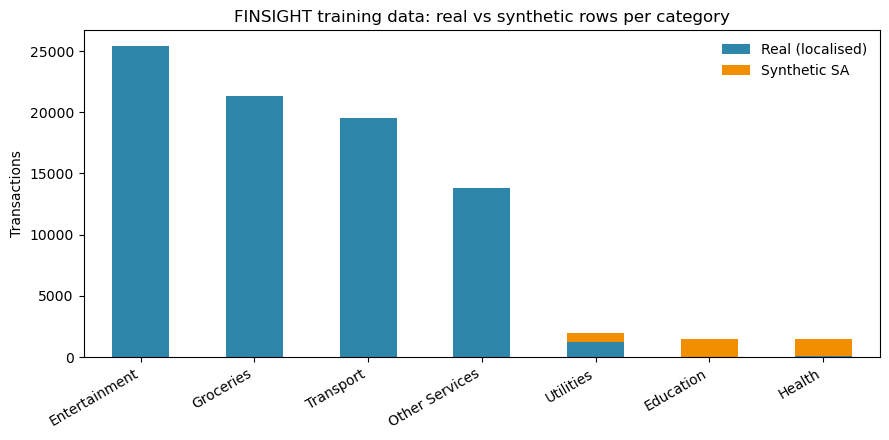

In [20]:
import matplotlib.pyplot as plt

counts = data.groupby(["category_7", "is_synthetic"]).size().unstack(fill_value=0)
counts = counts.loc[counts.sum(axis=1).sort_values(ascending=False).index]

ax = counts.plot(kind="bar", stacked=True, figsize=(9, 4.5), color=["#2E86AB", "#F18F01"])
ax.set_title("FINSIGHT training data: real vs synthetic rows per category")
ax.set_xlabel(""); ax.set_ylabel("Transactions")
ax.legend(["Real (localised)", "Synthetic SA"], frameon=False)
plt.xticks(rotation=30, ha="right"); plt.tight_layout()
plt.savefig(OUT_DIR / "fig_class_balance.png", dpi=200)
plt.show()